##### In this we are creating the two sperate graphs and the second graph is invoked into the first main graph and there state witll be seperate

In [28]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

True

In [29]:
class SubState(TypedDict):

      input_text : str
      translated_text : str

In [30]:
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.7)

In [31]:
def translater(state : SubState):

      prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state['input_text']}
"""
      result = subgraph_llm.invoke(prompt).content

      return {"translated_text" : result}

In [32]:
subgraphbuild = StateGraph(SubState)

subgraphbuild.add_node("translater", translater)

subgraphbuild.add_edge(START, "translater")
subgraphbuild.add_edge("translater", END)

subgraph = subgraphbuild.compile()

In [33]:
class ParentState(TypedDict):

      question : str
      answer_eng : str
      answer_hin : str

In [34]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.7)

In [35]:
def generate(state : ParentState):

      prompt = f"""
You are an helpful asistant.
Answer the question with clearity and keep it natural.

Question:
{state['question']}
"""
      result = parent_llm.invoke(prompt).content

      return {"answer_eng" : result}

In [36]:
def translate_ans(state : ParentState):

      # invoking the subgraph
      result = subgraph.invoke({"input_text" : state['answer_eng']})

      return {"answer_hin" : result['translated_text']}

In [37]:
parentbuild = StateGraph(ParentState)

parentbuild.add_node("generate", generate)
parentbuild.add_node("translate_ans", translate_ans)

parentbuild.add_edge(START, "generate")
parentbuild.add_edge("generate", "translate_ans")
parentbuild.add_edge("translate_ans", END)

parentgraph = parentbuild.compile()

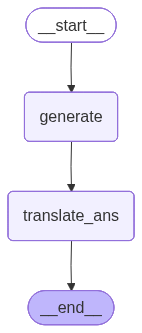

In [38]:
parentgraph

In [39]:
parentgraph.invoke({'question' : 'What is quantum Physics and also tell me about the god particle'})

{'question': 'What is quantum Physics and also tell me about the god particle',
 'answer_eng': 'To put it simply, **Quantum Physics** is the study of the universe at its smallest possible level—the world of atoms and subatomic particles (like electrons and photons).\n\nAt our human scale, things follow "Classical Physics." If you throw a ball, you know exactly where it is and how fast it’s going. But in the quantum world, the rules change completely and get very weird. Here are the three big ideas:\n\n1.  **Probability, not Certainty:** Particles don’t exist in one specific spot. Instead, they exist in a "cloud" of possibilities. You only know where a particle is once you actually measure it.\n2.  **Superposition:** A particle can technically be in two states or places at the exact same time until it is observed. (This is the basis for the famous "Schrödinger\'s Cat" thought experiment).\n3.  **Entanglement:** Two particles can become "linked." If you change something about one, the ot